<a href="https://colab.research.google.com/github/Paras1719/NNDL-practicals/blob/main/NNDL_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

In [4]:
np.random.seed(42)

# Generate normal sensor data
time = np.arange(1000)

temperature = 50 + 2 * np.sin(time / 20) + np.random.normal(0, 0.5, 1000)

# Add abnormal/anomalous values
temperature[700:710] += 10
temperature[850:860] -= 8

# Create DataFrame
data = pd.DataFrame({
    'Temperature': temperature
})

print(data.head())

   Temperature
0    50.248357
1    50.030826
2    50.523511
3    51.060391
4    50.280262


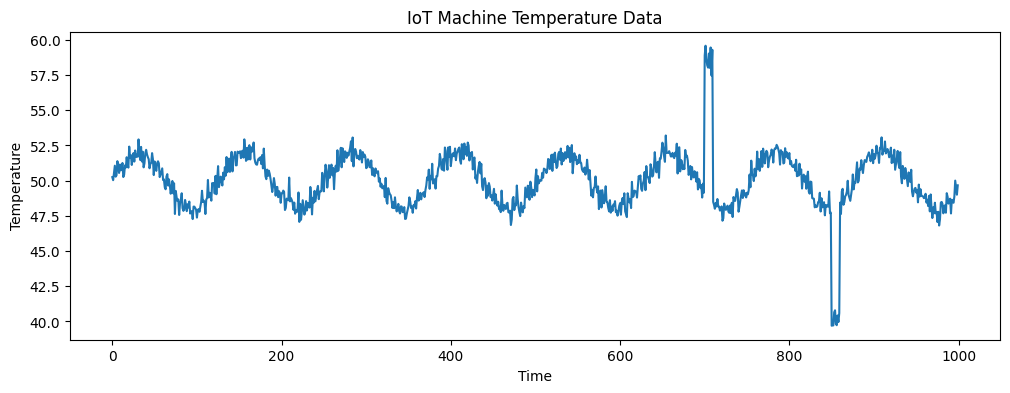

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(data['Temperature'])
plt.title("IoT Machine Temperature Data")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

In [6]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    data[['Temperature']]
)

print(scaled_data[:5])

[[0.53071978]
 [0.51977902]
 [0.5445587 ]
 [0.57156118]
 [0.53232444]]


In [7]:
sequence_length = 30

X = []

for i in range(len(scaled_data) - sequence_length):
    X.append(scaled_data[i:i + sequence_length])

X = np.array(X)

print("Shape of input sequences:", X.shape)

Shape of input sequences: (970, 30, 1)


In [8]:
timesteps = X.shape[1]
features = X.shape[2]

# Input layer
inputs = Input(shape=(timesteps, features))

# Encoder
encoded = LSTM(64, activation='relu')(inputs)

# Repeat encoded representation
decoded = RepeatVector(timesteps)(encoded)

# Decoder
decoded = LSTM(64, activation='relu', return_sequences=True)(decoded)

# Output layer
outputs = TimeDistributed(Dense(features))(decoded)

# Create model
autoencoder = Model(inputs, outputs)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

history = autoencoder.fit(
    X,
    X,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0926 - val_loss: 0.0348
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0215 - val_loss: 0.0225
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0139 - val_loss: 0.0171
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0095 - val_loss: 0.0129
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0065 - val_loss: 0.0108
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0050 - val_loss: 0.0099
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0043 - val_loss: 0.0088
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0038 - val_loss: 0.0089
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0035 - val_loss: 0.0084
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0033 - val_loss: 0.0087
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0033 - val_loss: 0.0082
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0

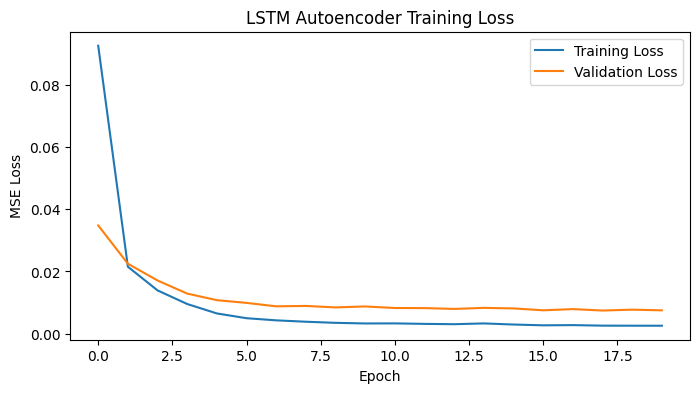

In [10]:
plt.figure(figsize=(8, 4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [11]:
X_pred = autoencoder.predict(X)

# Calculate Mean Squared Error for every sequence
reconstruction_error = np.mean(
    np.square(X - X_pred),
    axis=(1, 2)
)

print("First 10 reconstruction errors:")
print(reconstruction_error[:10])

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step
First 10 reconstruction errors:
[0.00083961 0.00080523 0.00093475 0.0008955  0.00085273 0.00086625
 0.00076823 0.00074907 0.00077949 0.00072862]


In [16]:
threshold = np.mean(reconstruction_error) + 3 * np.std(reconstruction_error)

print("Anomaly Threshold:", threshold)
anomalies = reconstruction_error > threshold

print("Number of anomalies:", np.sum(anomalies))

Anomaly Threshold: 0.03038638059457798
Number of anomalies: 39


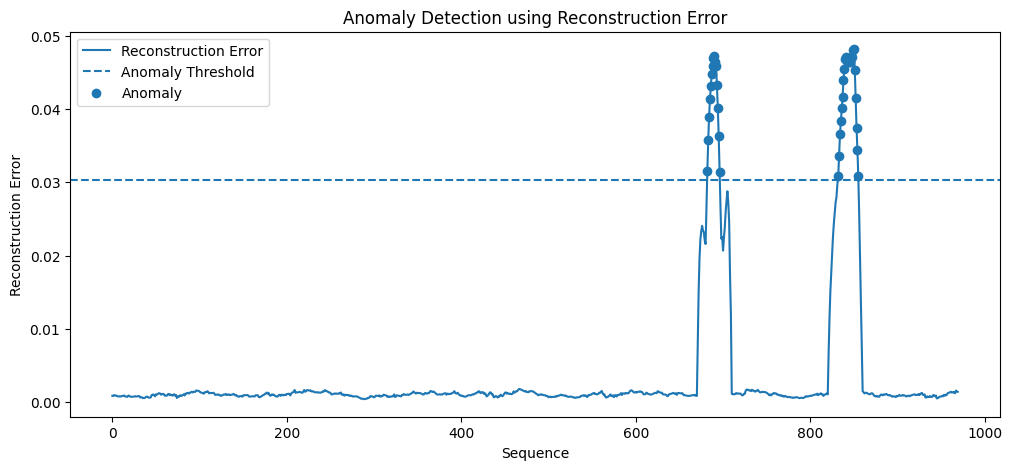

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(reconstruction_error, label='Reconstruction Error')

plt.axhline(
    threshold,
    linestyle='--',
    label='Anomaly Threshold'
)

plt.scatter(
    np.where(anomalies)[0],
    reconstruction_error[anomalies],
    label='Anomaly'
)

plt.title("Anomaly Detection using Reconstruction Error")
plt.xlabel("Sequence")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.show()

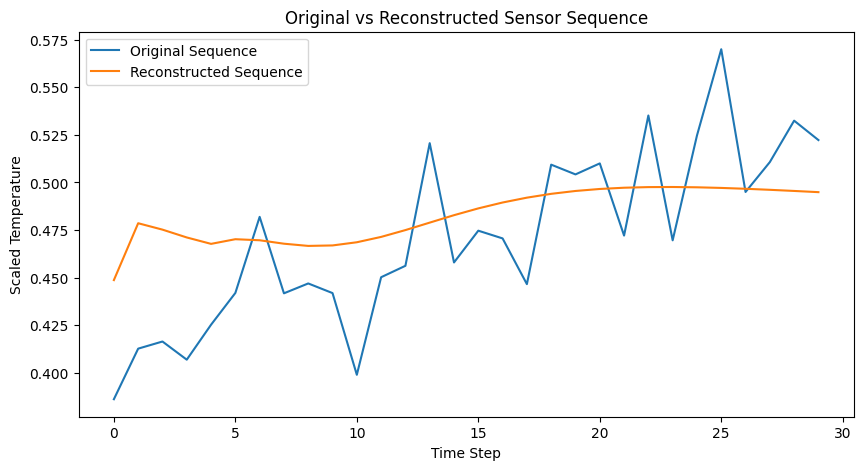

In [18]:
sample = 100

plt.figure(figsize=(10, 5))

plt.plot(
    X[sample].flatten(),
    label='Original Sequence'
)

plt.plot(
    X_pred[sample].flatten(),
    label='Reconstructed Sequence'
)

plt.title("Original vs Reconstructed Sensor Sequence")
plt.xlabel("Time Step")
plt.ylabel("Scaled Temperature")
plt.legend()

plt.show()

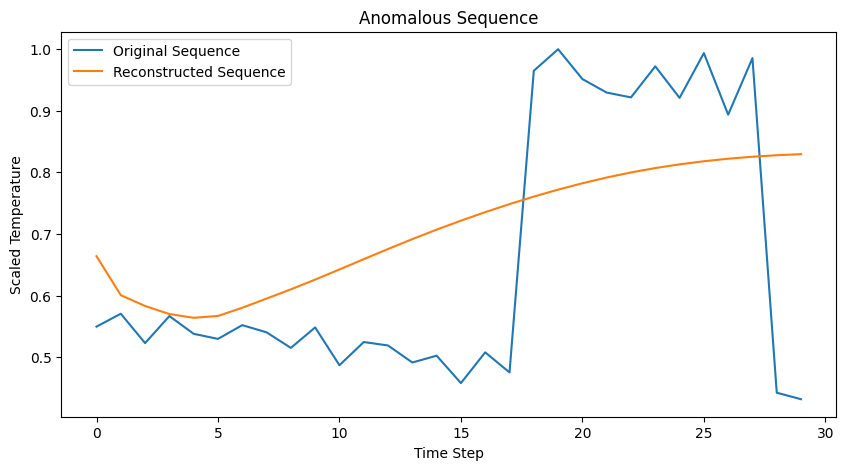

In [19]:
anomaly_indices = np.where(anomalies)[0]

if len(anomaly_indices) > 0:

    sample = anomaly_indices[0]

    plt.figure(figsize=(10, 5))

    plt.plot(
        X[sample].flatten(),
        label='Original Sequence'
    )

    plt.plot(
        X_pred[sample].flatten(),
        label='Reconstructed Sequence'
    )

    plt.title("Anomalous Sequence")
    plt.xlabel("Time Step")
    plt.ylabel("Scaled Temperature")
    plt.legend()

    plt.show()

In [20]:
loss = autoencoder.evaluate(X, X, verbose=0)

print("Reconstruction Loss (MSE):", loss)
print("Anomaly Threshold:", threshold)
print("Total Anomalies Detected:", np.sum(anomalies))

Reconstruction Loss (MSE): 0.0034712827764451504
Anomaly Threshold: 0.03038638059457798
Total Anomalies Detected: 39
